In [9]:
import pandas as pd
import numpy as np

# Loading the data
# We use sep='\t' because the data from cBioPortal are Tab-separated

mutations = pd.read_csv('data/data_mutations.txt', sep='\t', low_memory=False)
rna_seq = pd.read_csv('data/data_mrna_seq_v2_rsem.txt', sep='\t')

# Finding the samples with a mutation in PIK3CA

# Filtering the column Hugo_Symbol

pik3ca_muts = mutations[mutations['Hugo_Symbol'] == 'PIK3CA' ]

# Acquiring the unique barcodes of patients that have the mutation 

mutant_samples = pik3ca_muts['Tumor_Sample_Barcode'].unique()

print(f"{len(mutant_samples)} samples with a mutation in PIK3CA were found.")

# Preparing the RNA-seq matrix

rna_seq = rna_seq.dropna(subset=['Hugo_Symbol']) # dropping the unnamed genes
rna_seq = rna_seq.set_index('Hugo_Symbol') # setting a column with the names of the genes as index
rna_seq = rna_seq.drop(columns=['Entrez_Gene_Id']) 

# Dividing the samples into 2 groups

all_samples = rna_seq.columns.tolist()

# Attention: The IDs in mutations and in rna_seq may differ (e.g. -01 in the end)
# We will do a clean-up to be sure that they match

mutant_group = [s for s in all_samples if any(m in s for m in mutant_samples)]
wt_group = [s for s in all_samples if s not in mutant_group]

print(f"Group Mutant: {len(mutant_group)} samples")
print(f"Group Wild-Type (WT): {len(wt_group)} samples")

# Creating the final matrix για το DESeq2

final_counts = rna_seq[mutant_group + wt_group]

# Conversion to integers (necessary for DESeq2)

final_counts = final_counts.round().astype(int)


53 samples with a mutation in PIK3CA were found.
Group Mutant: 52 samples
Group Wild-Type (WT): 254 samples


In [10]:
# Filtering the genes with lowcounts

# Calculating the sum of the counts for each gene (each row)

genes_to_keep = final_counts.sum(axis=1) >= 10

# Filtering the table

final_counts_filtered = final_counts[genes_to_keep]

print(f"Initial Number of genes: {len(final_counts)}")
print(f"Number of genes after the filtering : {len(final_counts_filtered)}")
print(f"There were removed {len(final_counts) - len(final_counts_filtered)} genes with very low expression.")


Initial Number of genes: 20530
Number of genes after the filtering : 19431
There were removed 1099 genes with very low expression.


In [11]:
# Transpose of the table

counts_ready = final_counts_filtered.T

# Creating of the Metadata DataFrame

metadata = pd.DataFrame(index=counts_ready.index)
metadata['condition'] = ['Mutant' if x in mutant_group else 'WT' for x in metadata.index]

# Conversion of the column condition in 'category' (needed for PyDESeq2)

metadata['condition'] = metadata['condition'].astype('category')

print("\nMetadata table head:")
print(metadata.head())

# Checking for duplicate genes

print(f"Duplicates found: {final_counts_filtered.index.duplicated().sum()}")

# If diplucates are found, we cluster them taking the maximum (or the sum)
# Each Hugo_Symbol will be unique

final_counts_unique = final_counts_filtered.groupby(level=0).max()

# We redo the transposing

counts_ready = final_counts_unique.T

# We make sure that the metadata has also unique indexes and matches.

metadata = metadata.loc[counts_ready.index]

print(f"New table (Samples, Genes): {counts_ready.shape}")


Metadata table head:
                condition
TCGA-C5-A1BE-01    Mutant
TCGA-C5-A1BJ-01    Mutant
TCGA-C5-A1BM-01    Mutant
TCGA-C5-A1BQ-01    Mutant
TCGA-C5-A1MH-01    Mutant
Duplicates found: 16
New table (Samples, Genes): (306, 19415)


In [5]:
pip install pydeseq2

Note: you may need to restart the kernel to use updated packages.


In [12]:
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats

# Creating the DeseqDataSeq item.

dds = DeseqDataSet(
    counts=counts_ready, 
    metadata=metadata, 
    design_factors="condition", 
    refit_cooks=True, 
    n_cpus=-1
)

# Running DESeq2 (Estimation of dispersions & Log fold changes)
dds.deseq2()

# Extracting the results (Contrast: Mutant vs WT)
# We set the control group ars the 'WT'

stat_res = DeseqStats(dds, contrast=["condition", "Mutant", "WT"], n_cpus=-1)
stat_res.summary()

# Saving the dataframe

results_df = stat_res.results_df

C:\Users\agiri\AppData\Local\Temp\ipykernel_26132\2387468529.py:6: DeprecationWarning: design_factors is deprecated and will soon be removed.Please consider providing a formulaic formula using the design argumentinstead.
  dds = DeseqDataSet(
Fitting size factors...


Using None as control genes, passed at DeseqDataSet initialization


... done in 0.59 seconds.

Fitting dispersions...
... done in 16.82 seconds.

Fitting dispersion trend curve...
... done in 1.12 seconds.

Fitting MAP dispersions...
... done in 15.31 seconds.

Fitting LFCs...
... done in 8.02 seconds.

Calculating cook's distance...
... done in 0.94 seconds.

Replacing 2875 outlier genes.

Fitting dispersions...
... done in 2.10 seconds.

Fitting MAP dispersions...
... done in 2.24 seconds.

Fitting LFCs...
... done in 2.21 seconds.

Running Wald tests...
... done in 3.54 seconds.



Log2 fold change & Wald test p-value: condition Mutant vs WT
                baseMean  log2FoldChange     lfcSE      stat    pvalue  \
Hugo_Symbol                                                              
133K02        280.990110        0.148659  0.074209  2.003243  0.045151   
5T4          1409.178645       -0.197785  0.127252 -1.554280  0.120118   
A-C1           57.191076        0.531524  0.331137  1.605149  0.108461   
A1BG           77.759794        0.140167  0.196858  0.712022  0.476451   
A1BG-AS1       61.972679       -0.051010  0.181449 -0.281126  0.778614   
...                  ...             ...       ...       ...       ...   
ZXDC         1300.458854       -0.140799  0.071815 -1.960579  0.049928   
ZYG11A        125.045843       -0.185399  0.207054 -0.895410  0.370568   
ZYG11B        641.725320       -0.107224  0.069172 -1.550105  0.121116   
ZYX          4052.583211        0.027966  0.111953  0.249801  0.802741   
ZZZ3          735.235829       -0.133167  0.068293 

In [13]:
# Saving the results

results_df.to_csv('results/differential_expression_results.csv')

# Filtering and saving only the statistically significant genes

significant_genes = results_df[(results_df['padj'] < 0.05) & (results_df['log2FoldChange'].abs() > 1)]

significant_genes.to_csv('results/significant_DEGs_PIK3CA.csv')

print("The files are successfully saved in the folder results/")


The files are successfully saved in the folder results/


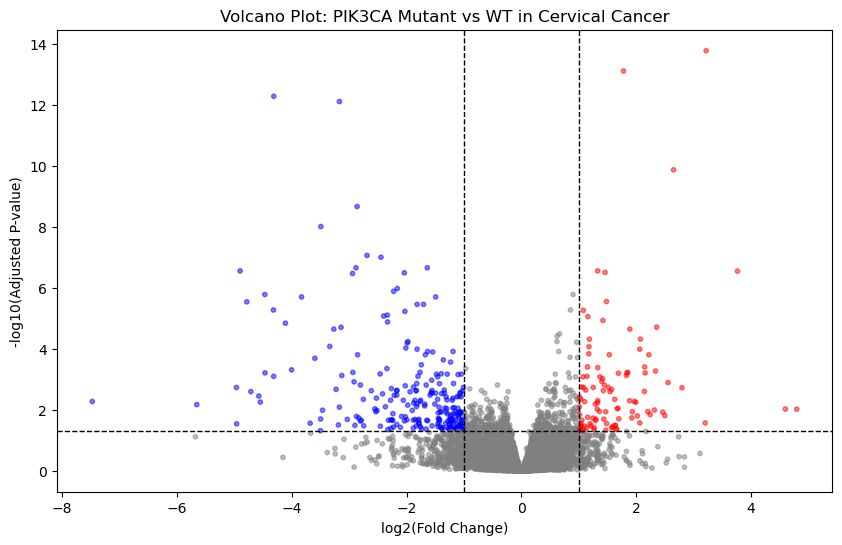

<Figure size 640x480 with 0 Axes>

In [14]:
import matplotlib.pyplot as plt
import numpy as np

# Red color is for significant up-regulated genes, Blue is for statistically down-regulated and Grey is for the rest 

results_df['color'] = 'grey'
results_df.loc[(results_df['padj'] < 0.05) & (results_df['log2FoldChange'] > 1), 'color'] = 'red'
results_df.loc[(results_df['padj'] < 0.05) & (results_df['log2FoldChange'] < -1), 'color'] = 'blue'

plt.figure(figsize=(10, 6))
plt.scatter(results_df['log2FoldChange'], -np.log10(results_df['padj']), 
            c=results_df['color'], alpha=0.5, s=10)

plt.axhline(-np.log10(0.05), color='black', linestyle='--', lw=1) # p-value threshold
plt.axvline(1, color='black', linestyle='--', lw=1)  # FC threshold
plt.axvline(-1, color='black', linestyle='--', lw=1) # FC threshold

plt.title('Volcano Plot: PIK3CA Mutant vs WT in Cervical Cancer')
plt.xlabel('log2(Fold Change)')
plt.ylabel('-log10(Adjusted P-value)')
plt.show()

plt.savefig("results/volcano_plot.png", dpi=300, bbox_inches='tight')

In [ ]:
pip install gseapy


Number of genes to be analyzed: 203
                                                 Term Overlap   P-value  \
0       cellular response to cadmium ion (GO:0071276)    4/27  0.000151   
1129    cellular response to cadmium ion (GO:0071276)    4/27  0.000151   
1130             response to cadmium ion (GO:0046686)    4/29  0.000201   
1                response to cadmium ion (GO:0046686)    4/29  0.000201   
2                  generation of neurons (GO:0048699)   9/202  0.000229   
1131               generation of neurons (GO:0048699)   9/202  0.000229   
1132                endoderm development (GO:0007492)    3/15  0.000428   
3                   endoderm development (GO:0007492)    3/15  0.000428   
4     central nervous system development (GO:0007417)  10/268  0.000429   
1133  central nervous system development (GO:0007417)  10/268  0.000429   

      Adjusted P-value  
0             0.086054  
1129          0.086054  
1130          0.086054  
1             0.086054  
2            

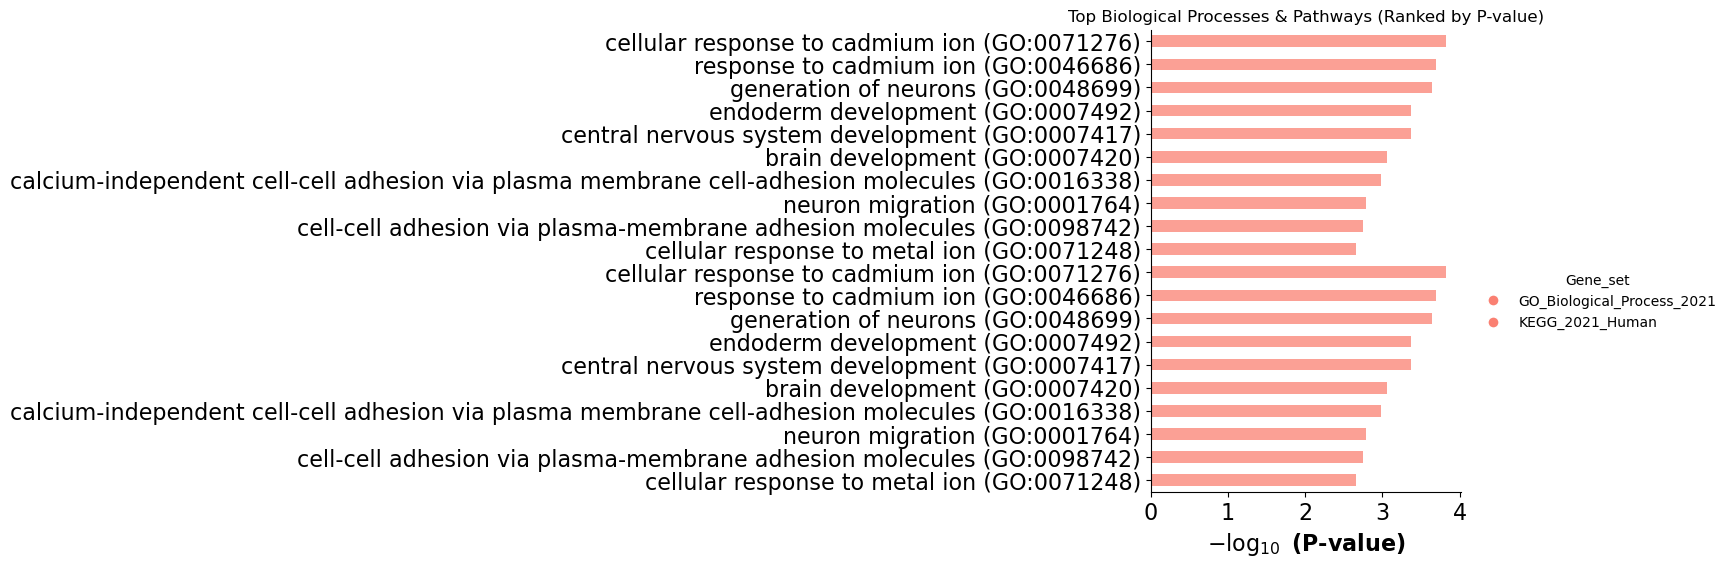

<Figure size 640x480 with 0 Axes>

In [17]:
import gseapy as gp
import matplotlib.pyplot as plt

# We losen the filter to have more genes (log2FC > 0.5 instead of 1)

gene_list = results_df[(results_df['padj'] < 0.05) & (results_df['log2FoldChange'] > 0.5)].index.tolist()

print(f"Number of genes to be analyzed: {len(gene_list)}")

# We run the analysis trying KEGG  and GO at the same time

enr = gp.enrichr(gene_list=gene_list,
                 gene_sets=['KEGG_2021_Human', 'GO_Biological_Process_2021'],
                 organism='human', 
                 outdir=None)

# We filter the results to see what was found, even if it isnt <0.05.

results = enr.results
if not results.empty:
    # Sort by P-value (even if it is > 0.05, to see trends)
    top_results = results.sort_values('P-value').head(10)
    print(top_results[['Term', 'Overlap', 'P-value', 'Adjusted P-value']])
    
    #Visualization without a strict cutoff to see what's happening in the background
    
    gp.barplot(results, column="P-value", group='Gene_set', size=10, top_term=10)
    plt.title('Top Biological Processes & Pathways (Ranked by P-value)')
    plt.show()
    plt.savefig("results/pathway_enrichment.png", dpi=300, bbox_inches='tight')
    enr.results.to_csv("results/enrichment_analysis_results.csv")
else:
    print("Unfortunately, no results were found. We may need to check the gene list..")

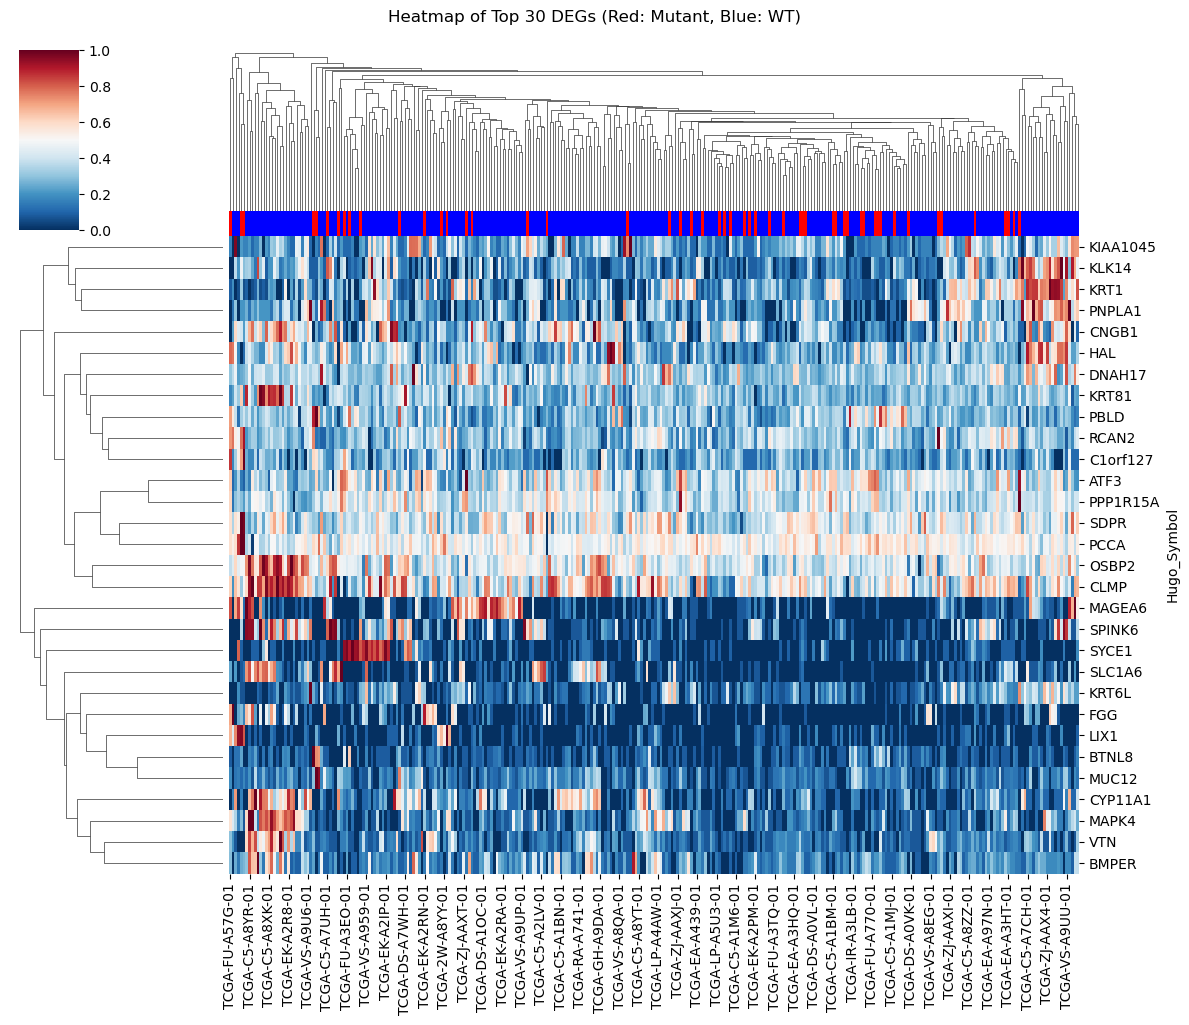

<Figure size 640x480 with 0 Axes>

In [16]:
import seaborn as sns

# Selecting the top 30 genes based on p-value

top_genes = results_df.nsmallest(30, 'padj').index

# Obtaining the normalized data (log2 transformation)

heatmap_data = np.log2(counts_ready[top_genes].T + 1)

# Creating the clustermap 

g = sns.clustermap(heatmap_data, 
                   cmap='RdBu_r', 
                   standard_scale=0, # Normalization per gene
                   col_colors=['red' if x in mutant_group else 'blue' for x in heatmap_data.columns],
                   figsize=(12, 10))

g.fig.suptitle('Heatmap of Top 30 DEGs (Red: Mutant, Blue: WT)', y=1.02)
plt.show()
plt.savefig("results/heatmap_top30.png", dpi=300, bbox_inches='tight')